# Used Cars Data Cleaning and Exploratory Analysis

This notebook analyzes the used car dataset in `train.csv`.

The workflow covers:

- missing-value analysis and data cleaning
- unit removal and numeric conversion
- one-hot encoding for categorical fields
- feature creation
- dataframe operations with interpretable outputs
- exploratory analysis with saved plots and written findings

All outputs are generated from the raw data in `../data_raw/` and saved into the matching `data_clean/` and `reports/figures/` folders.


In [10]:
from __future__ import annotations

import os
from pathlib import Path

# Keep temporary Matplotlib cache files outside the project folder.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_assignment2_q1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

NOTEBOOK_DIR = Path.cwd()
DATA_CLEAN_DIR = (NOTEBOOK_DIR / "../data_clean").resolve()
FIGURES_DIR = (NOTEBOOK_DIR / "../reports/figures").resolve()
DATA_CLEAN_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def resolve_path(*candidates: str) -> Path:
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find any of: {candidates}")


def extract_numeric(series: pd.Series) -> pd.Series:
    """Keep only the numeric portion of a text-based field."""
    return pd.to_numeric(
        series.astype(str).str.extract(r"([0-9]+\.?[0-9]*)", expand=False),
        errors="coerce",
    )


def save_figure(fig: plt.Figure, filename: str) -> None:
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure: {output_path}")


DATA_PATH = resolve_path("../data_raw/train.csv", "Assignment_2/Question1/data_raw/train.csv")
cars_raw = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {cars_raw.shape[0]} rows x {cars_raw.shape[1]} columns")
print(f"Unique locations: {cars_raw['Location'].nunique()}")
print(f"Unique fuel types: {cars_raw['Fuel_Type'].nunique()}")
display(cars_raw.describe(include="all").transpose().fillna(""))


Dataset path: ../data_raw/train.csv
Shape: 5847 rows x 14 columns
Unique locations: 11
Unique fuel types: 3


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,5847.0,,,,3013.181461,1736.39889,1.0,1509.5,3015.0,4517.5,6018.0
Name,5847,1804,Mahindra XUV500 W8 2WD,49,,,,,,,
Location,5847,11,Mumbai,762,,,,,,,
Year,5847.0,,,,2013.448435,3.194949,1998.0,2012.0,2014.0,2016.0,2019.0
Kilometers_Driven,5847.0,,,,58410.134599,92379.712368,171.0,33467.5,52576.0,72490.5,6500000.0
Fuel_Type,5847,3,Diesel,3161,,,,,,,
Transmission,5847,2,Manual,4135,,,,,,,
Owner_Type,5847,4,First,4811,,,,,,,
Mileage,5845,419,18.9 kmpl,172,,,,,,,
Engine,5811,140,1197 CC,602,,,,,,,


## Part (a): Missing values and justification

The raw dataset contains only a few missing values in `Mileage`, `Engine`, `Power`, and `Seats`, but `New_Price` is missing in most rows.

Cleaning decisions:

- `Mileage`, `Engine`, and `Power` are continuous variables with low missingness, so median imputation is appropriate.
- `Seats` is a count variable, so mode imputation is appropriate.
- `New_Price` is first converted into numeric form for the unit-removal task, then dropped from the final cleaned working dataframe because more than 86% of values are missing.
- `Unnamed: 0` is only an imported row-number column and is removed.


In [11]:
missing_summary = (
    cars_raw.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda df: (df["missing_count"] / len(cars_raw) * 100).round(2))
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)


,missing_count,missing_percent
New_Price,5032,86.06
Seats,38,0.65
Engine,36,0.62
Power,36,0.62
Mileage,2,0.03


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question1/reports/figures/q1_missing_values.png


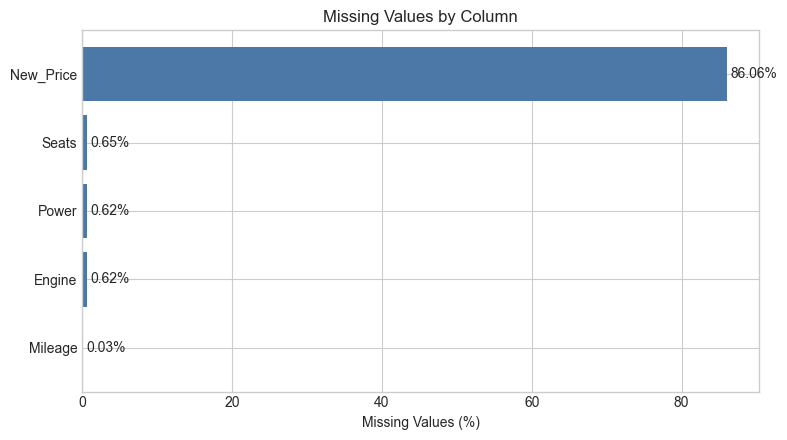

In [12]:
# Visualize the missingness so the imbalance in New_Price is easy to see.
missing_plot = missing_summary.sort_values("missing_percent")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(missing_plot.index, missing_plot["missing_percent"], color="#4C78A8")
ax.set_xlabel("Missing Values (%)")
ax.set_title("Missing Values by Column")

for bar, value in zip(bars, missing_plot["missing_percent"]):
    ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f"{value:.2f}%", va="center")

plt.tight_layout()
save_figure(fig, "q1_missing_values.png")
plt.show()


## Parts (b), (c), and (d): Cleaning, encoding, and feature creation

This step removes text units, fills the selected missing values, creates `Car_Age`, and then one-hot encodes `Fuel_Type` and `Transmission`.
The final cleaned dataset is saved into `../data_clean/used_cars_cleaned.csv`.


In [13]:
# Work on a copy so the raw dataset remains unchanged.
cars_clean = cars_raw.copy()

# Remove the imported row counter.
cars_clean = cars_clean.drop(columns=["Unnamed: 0"])

# Remove text units and keep only numeric values.
cars_clean["Mileage"] = extract_numeric(cars_clean["Mileage"])
cars_clean["Engine"] = extract_numeric(cars_clean["Engine"])
cars_clean["Power"] = extract_numeric(cars_clean["Power"])

# Convert New_Price into numeric values measured in lakhs.
new_price_numeric = extract_numeric(cars_clean["New_Price"])
new_price_unit = cars_clean["New_Price"].astype(str).str.extract(r"(Lakh|Cr)", expand=False)
cars_clean["New_Price"] = np.where(new_price_unit.eq("Cr"), new_price_numeric * 100, new_price_numeric)

# Impute the low-missing numeric fields with the median.
median_imputes = cars_clean[["Mileage", "Engine", "Power"]].median()
cars_clean[["Mileage", "Engine", "Power"]] = cars_clean[["Mileage", "Engine", "Power"]].fillna(median_imputes)

# Impute Seats with the mode because it is a discrete count field.
seats_mode = cars_clean["Seats"].mode().iat[0]
cars_clean["Seats"] = cars_clean["Seats"].fillna(seats_mode)

# Drop New_Price after conversion because the column is too incomplete for reliable analysis.
cars_clean = cars_clean.drop(columns=["New_Price"])

# Create an additional feature based on the model year.
CURRENT_YEAR = pd.Timestamp.today().year
cars_clean["Car_Age"] = CURRENT_YEAR - cars_clean["Year"]

# Keep a one-hot encoded version for the later dataframe operations.
cars_encoded = pd.get_dummies(
    cars_clean.copy(),
    columns=["Fuel_Type", "Transmission"],
    dtype=int,
)

cars_encoded.to_csv(DATA_CLEAN_DIR / "used_cars_cleaned.csv", index=False)

print("Median values used for imputation:")
display(median_imputes.to_frame(name="value"))

print(f"Mode used for Seats: {seats_mode:.0f}")
print(f"Current year used for Car_Age: {CURRENT_YEAR}")
print(f"Cleaned dataset shape: {cars_encoded.shape}")
display(cars_encoded[["Price", "Mileage", "Engine", "Power", "Seats", "Car_Age"]].describe().round(2).transpose())


Median values used for imputation:


,value
Mileage,18.19
Engine,1497.00
Power,98.60


Mode used for Seats: 5
Current year used for Car_Age: 2026
Cleaned dataset shape: (5847, 16)


,count,mean,std,min,25%,50%,75%,max
Price,5847.0,9.65,11.28,0.44,3.55,5.75,10.25,160.0
Mileage,5847.0,18.16,4.36,0.00,15.26,18.19,21.10,28.4
Engine,5847.0,1630.72,600.21,72.00,1198.00,1497.00,1991.00,5998.0
Power,5847.0,113.71,53.74,34.20,78.00,98.60,138.10,560.0
Seats,5847.0,5.28,0.80,2.00,5.00,5.00,5.00,10.0
Car_Age,5847.0,12.55,3.19,7.00,10.00,12.00,14.00,28.0


## Part (e): Dataframe operations with meaningful outputs

For `select`, `filter`, `rename`, `mutate`, `arrange`, and `summarize/group by`.
Below, each operation is applied and then used to produce interpretable summaries instead of being left unused.


In [21]:
# SELECT: keep a subset of columns that are useful for pricing analysis.
selected_cars = cars_encoded[
    [
        "Name",
        "Location",
        "Price",
        "Kilometers_Driven",
        "Car_Age",
        "Fuel_Type_Diesel",
        "Fuel_Type_Electric",
        "Fuel_Type_Petrol",
        "Transmission_Automatic",
        "Transmission_Manual",
    ]
]

# FILTER: isolate relatively newer vehicles with a higher selling price.
filtered_cars = cars_encoded.query("Price > 10 and Car_Age <= 5")[
    ["Name", "Location", "Price", "Car_Age"]
]

# RENAME: make column names clearer for interpretation.
renamed_cars = cars_encoded.rename(
    columns={
        "Kilometers_Driven": "Odometer_Km",
        "Price": "Used_Car_Price_Lakh",
    }
)

# MUTATE: derive two comparison-friendly features.
mutated_cars = renamed_cars.assign(
    Price_per_Year=lambda df: (
        df["Used_Car_Price_Lakh"] / df["Car_Age"].replace(0, np.nan)
    ).round(2),
    Km_per_Year=lambda df: (
        df["Odometer_Km"] / df["Car_Age"].replace(0, np.nan)
    ).round(2),
)

# ARRANGE: rank cars by selling price and then by engine power.
arranged_cars = mutated_cars.sort_values(
    by=["Used_Car_Price_Lakh", "Power"],
    ascending=[False, False],
)

# SUMMARIZE + GROUP BY: compare pricing patterns by location using every row in the dataset.
group_summary = (
    mutated_cars.groupby("Location", as_index=False)
    .agg(
        Average_Price_Lakh=("Used_Car_Price_Lakh", "mean"),
        Median_Mileage=("Mileage", "median"),
        Average_Car_Age=("Car_Age", "mean"),
        Listing_Count=("Name", "count"),
    )
    .sort_values("Average_Price_Lakh", ascending=False)
)

# Additional summary by segment to support later interpretation.
segment_summary = (
    cars_clean.groupby(["Fuel_Type", "Transmission"], as_index=False)
    .agg(
        Average_Price_Lakh=("Price", "mean"),
        Median_Km=("Kilometers_Driven", "median"),
        Average_Car_Age=("Car_Age", "mean"),
        Listing_Count=("Name", "count"),
    )
    .sort_values("Average_Price_Lakh", ascending=False)
)

selected_summary = (
    selected_cars.groupby("Location", as_index=False)
    .agg(
        Listings=("Name", "count"),
        Average_Price_Lakh=("Price", "mean"),
        Median_Car_Age=("Car_Age", "median"),
    )
    .sort_values("Average_Price_Lakh", ascending=False)
)

filtered_summary = (
    filtered_cars.groupby("Location", as_index=False)
    .agg(
        Filtered_Listings=("Name", "count"),
        Average_Filtered_Price=("Price", "mean"),
        Median_Filtered_Age=("Car_Age", "median"),
    )
    .sort_values("Average_Filtered_Price", ascending=False)
)

mutated_summary = mutated_cars[
    ["Used_Car_Price_Lakh", "Odometer_Km", "Car_Age", "Price_per_Year", "Km_per_Year"]
].describe().round(2)

arranged_extremes = pd.concat(
    [
        arranged_cars[["Name", "Location", "Used_Car_Price_Lakh", "Power"]].head(5),
        arranged_cars[["Name", "Location", "Used_Car_Price_Lakh", "Power"]].tail(5),
    ],
    keys=["Highest priced cars", "Lowest priced cars"],
)

group_summary.to_csv(DATA_CLEAN_DIR / "location_price_summary.csv", index=False)
segment_summary.to_csv(DATA_CLEAN_DIR / "segment_price_summary.csv", index=False)

print("Select operation summary based on the full selected dataset:")
display(selected_summary.round(2))

print("Filter operation summary based on all rows that satisfy the rule:")
display(filtered_summary.round(2))

print("Rename + mutate summary across the full dataset:")
display(mutated_summary)

print("Arrange operation results after sorting the full dataset:")
display(arranged_extremes)

print("Summarize with group by example using all locations:")
display(group_summary.round(2))

print("Fuel + transmission segment summary:")
display(segment_summary.round(2))


Select operation summary based on the full selected dataset:


,Location,Listings,Average_Price_Lakh,Median_Car_Age
3,Coimbatore,631,15.16,10.0
1,Bangalore,352,13.48,13.0
7,Kochi,640,11.31,10.0
5,Hyderabad,710,10.00,13.0
4,Delhi,540,9.88,12.0
9,Mumbai,762,9.59,12.0
0,Ahmedabad,218,8.57,12.0
2,Chennai,476,7.96,14.0
10,Pune,590,6.95,13.0
6,Jaipur,403,5.92,13.0


Filter operation summary based on all rows that satisfy the rule:


,Location,Filtered_Listings,Average_Filtered_Price,Median_Filtered_Age


Rename + mutate summary across the full dataset:


...

Name  \
Highest priced cars 3952  Land Rover Range Rover 3.0 Diesel LWB Vogue   
                    5620                   Lamborghini Gallardo Coupe   
                    5752                       Jaguar F Type 5.0 V8 S   
                    1457              Land Rover Range Rover Sport SE   
                    1917                           BMW 7 Series 740Li   
Lowest priced cars  2520                                 Tata Nano Cx   
                    2758                             Hyundai Getz GLS   
                    3039                               Maruti Zen LXI   
                    1577                         Maruti 800 Std BSIII   
                    1660                                 Tata Nano Lx   

                            Location  Used_Car_Price_Lakh  Power  
Highest priced cars 3952   Hyderabad               160.00  255.0  
                    5620       Delhi               120.00  560.0  
                    5752   Hyderabad               100.00  488.1  
                    1457       Kochi                97.07  255.0  
                    1917  Coimbatore                93.67  320.0  
Lowest priced cars  2520      Jaipur                 0.50   35.0  
                    2758        Pune                 0.45   83.0  
                    3039      Jaipur                 0.45   60.0  
                    1577      Jaipur                 0.45   37.0  
                    1660        Pune                 0.44   35.0

Summarize with group by example using all locations:


,Location,Average_Price_Lakh,Median_Mileage,Average_Car_Age,Listing_Count
3,Coimbatore,15.16,18.15,10.58,631
1,Bangalore,13.48,17.00,13.16,352
7,Kochi,11.31,18.60,10.47,640
5,Hyderabad,10.00,19.00,13.17,710
4,Delhi,9.88,17.52,12.65,540
9,Mumbai,9.59,17.26,12.65,762
0,Ahmedabad,8.57,18.90,12.66,218
2,Chennai,7.96,18.13,13.93,476
10,Pune,6.95,17.80,13.58,590
6,Jaipur,5.92,19.30,13.39,403


Fuel + transmission segment summary:


,Fuel_Type,Transmission,Average_Price_Lakh,Median_Km,Average_Car_Age,Listing_Count
0,Diesel,Automatic,24.62,50000.0,11.94,1106
2,Electric,Automatic,12.88,47000.0,12.50,2
3,Petrol,Automatic,11.25,39000.0,12.45,604
1,Diesel,Manual,6.69,65000.0,12.36,2055
4,Petrol,Manual,4.16,45105.0,13.10,2080


## Deeper exploratory findings with plots

The next figures are saved into `../reports/figures/` so they are available both in the notebook and in the report folder.


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question1/reports/figures/q1_price_distribution.png


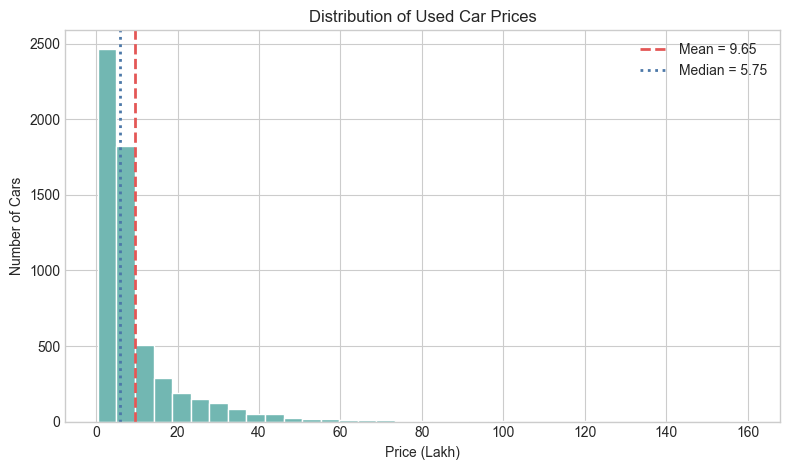

In [22]:
# Figure 1: overall price distribution.
price_mean = cars_clean["Price"].mean()
price_median = cars_clean["Price"].median()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(cars_clean["Price"], bins=35, color="#72B7B2", edgecolor="white")
ax.axvline(price_mean, color="#E45756", linestyle="--", linewidth=2, label=f"Mean = {price_mean:.2f}")
ax.axvline(price_median, color="#4C78A8", linestyle=":", linewidth=2, label=f"Median = {price_median:.2f}")
ax.set_title("Distribution of Used Car Prices")
ax.set_xlabel("Price (Lakh)")
ax.set_ylabel("Number of Cars")
ax.legend()

plt.tight_layout()
save_figure(fig, "q1_price_distribution.png")
plt.show()


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question1/reports/figures/q1_price_segments.png


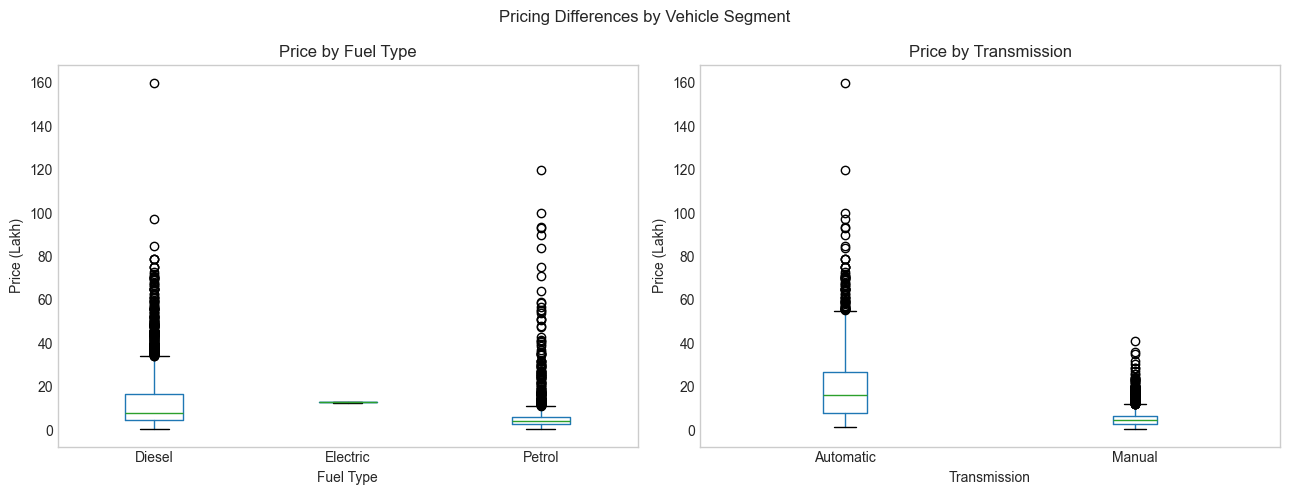

In [23]:
# Figure 2: compare price patterns across fuel type and transmission.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cars_clean.boxplot(column="Price", by="Fuel_Type", ax=axes[0], grid=False)
axes[0].set_title("Price by Fuel Type")
axes[0].set_xlabel("Fuel Type")
axes[0].set_ylabel("Price (Lakh)")

cars_clean.boxplot(column="Price", by="Transmission", ax=axes[1], grid=False)
axes[1].set_title("Price by Transmission")
axes[1].set_xlabel("Transmission")
axes[1].set_ylabel("Price (Lakh)")

fig.suptitle("Pricing Differences by Vehicle Segment")
plt.tight_layout()
save_figure(fig, "q1_price_segments.png")
plt.show()


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question1/reports/figures/q1_price_vs_age.png


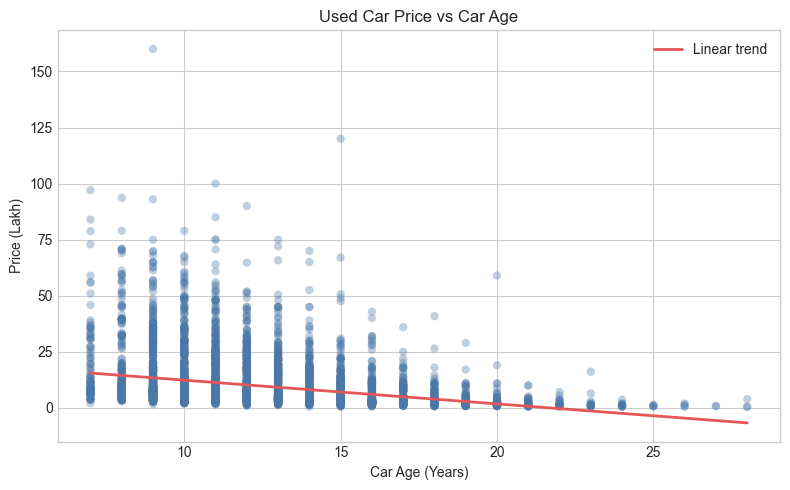

In [24]:
# Figure 3: examine how car age relates to selling price.
x = cars_clean["Car_Age"]
y = cars_clean["Price"]
trend = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = np.polyval(trend, x_line)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, alpha=0.35, color="#4C78A8", edgecolor="none")
ax.plot(x_line, y_line, color="#E45756", linewidth=2, label="Linear trend")
ax.set_title("Used Car Price vs Car Age")
ax.set_xlabel("Car Age (Years)")
ax.set_ylabel("Price (Lakh)")
ax.legend()

plt.tight_layout()
save_figure(fig, "q1_price_vs_age.png")
plt.show()


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question1/reports/figures/q1_top_locations.png


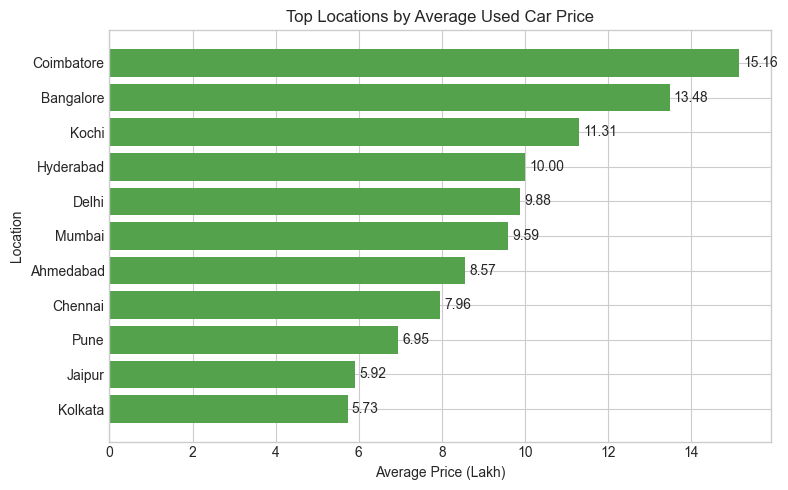

In [25]:
# Figure 4: compare the top locations by average selling price.
top_locations = group_summary.sort_values("Average_Price_Lakh")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top_locations["Location"], top_locations["Average_Price_Lakh"], color="#54A24B")
ax.set_title("Top Locations by Average Used Car Price")
ax.set_xlabel("Average Price (Lakh)")
ax.set_ylabel("Location")

for bar, value in zip(bars, top_locations["Average_Price_Lakh"]):
    ax.text(value + 0.1, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center")

plt.tight_layout()
save_figure(fig, "q1_top_locations.png")
plt.show()


Saved figure: /Users/jainil/PycharmProjects/PrincipleOfDataScienceAssignments/Assignment_2/Question1/reports/figures/q1_correlation_heatmap.png


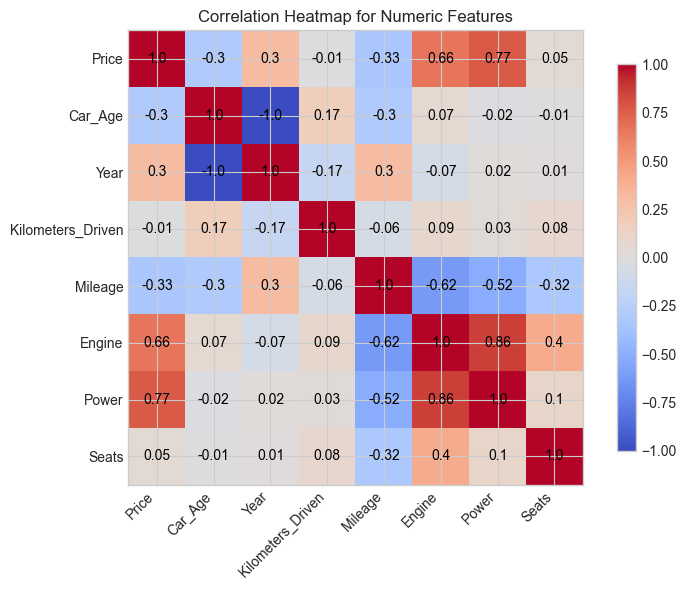

In [26]:
# Figure 5: correlation heatmap for the main numeric features.
numeric_columns = ["Price", "Car_Age", "Year", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats"]
corr_matrix = cars_clean[numeric_columns].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
heatmap = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlation Heatmap for Numeric Features")

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, corr_matrix.iloc[i, j], ha="center", va="center", color="black")

fig.colorbar(heatmap, ax=ax, shrink=0.85)
plt.tight_layout()
save_figure(fig, "q1_correlation_heatmap.png")
plt.show()


In [27]:
# Summarize the key quantitative findings from the exploratory analysis.
fuel_summary = cars_clean.groupby("Fuel_Type")["Price"].agg(["mean", "median", "count"]).round(2).sort_values("mean", ascending=False)
transmission_summary = cars_clean.groupby("Transmission")["Price"].agg(["mean", "median", "count"]).round(2).sort_values("mean", ascending=False)

display(fuel_summary)
display(transmission_summary)

print(f"Average price across the dataset: {price_mean:.2f} lakhs")
print(f"Median price across the dataset: {price_median:.2f} lakhs")
print(f"Correlation between price and car age: {cars_clean[['Price', 'Car_Age']].corr().iloc[0, 1]:.2f}")
print(f"Correlation between price and power: {cars_clean[['Price', 'Power']].corr().iloc[0, 1]:.2f}")
print(
    f"Highest average price by location: {group_summary.iloc[0]['Location']} "
    f"({group_summary.iloc[0]['Average_Price_Lakh']:.2f} lakhs)"
)
print(
    f"Highest average price segment: {segment_summary.iloc[0]['Fuel_Type']} / "
    f"{segment_summary.iloc[0]['Transmission']} "
    f"({segment_summary.iloc[0]['Average_Price_Lakh']:.2f} lakhs)"
)


,mean,median,count
Fuel_Type,,,
Diesel,12.96,7.85,3161
Electric,12.88,12.88,2
Petrol,5.76,4.20,2684


,mean,median,count
Transmission,,,
Automatic,19.89,16.00,1712
Manual,5.42,4.65,4135


Average price across the dataset: 9.65 lakhs
Median price across the dataset: 5.75 lakhs
Correlation between price and car age: -0.30
Correlation between price and power: 0.77
Highest average price by location: Coimbatore (15.16 lakhs)
Highest average price segment: Diesel / Automatic (24.62 lakhs)


## Final interpretation

- The missing-value analysis is shown both as a summary table and as a visual comparison.
- The dataframe operations lead into full-data summaries rather than small previews.
- The exploratory plots show how price changes across age, segment, and location.
- The cleaned outputs, figures, and report material remain organized in the project folders for easy review.
